# Day 08. Exercise 04
# Regression

## 0. Imports

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

## 1. Preprocessing

1. Read the file [`checker_regression.csv`](https://drive.google.com/file/d/1L8auBzJEghWFewznhhFpcrqxW4GqcfRY/view?usp=sharing).
2. Fill the missing values in it with `0`.
3. Make a split of your dataset on train and test with parameters `test_size=0.2`.

In [3]:
df = pd.read_csv('../data/checker_regression.csv')
df = df.groupby('uid').first().fillna(0)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 29 entries, user_1 to user_8
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   num_commits  29 non-null     int64  
 1   pageviews    29 non-null     float64
 2   AVG(diff)    29 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 928.0+ bytes


In [36]:
random_state = 21
test_size = 0.2

In [37]:
X = df.drop('AVG(diff)', axis=1)
y = df['AVG(diff)']

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=test_size,
    random_state=random_state
)

## 2. Crossvalidation

1. Write a function `crossval` that takes as arguments: `n_splits` for `KFold()`, `X`, `y`, model instantiated class with the parameters of the model (keep in mind: `random_state=21`) and returns for a given model class a result like this:

```
train -  2696.4496895424836   |   test -  1589.9979527104958
train -  2660.957874001452   |   test -  2075.102636027137
train -  2847.315529246795   |   test -  320.911928168403
train -  2500.7691099659237   |   test -  4132.461382030178
train -  2643.927917295123   |   test -  2237.8140952197878
train -  2396.295678819444   |   test -  4509.650064742476
train -  2003.402267924976   |   test -  8403.491474908551
train -  2531.876094212613   |   test -  3135.944102735099
train -  2683.1795186023123   |   test -  1796.01426292594
train -  2537.1192483996338   |   test -  3439.29824116941
Average RMSE on crossval is 3164.0686140637476
```

2. Run the function for `LinearRegression`, `DecisionTreeRegressor`, `RandomForestRegressor`. You may choose the parameters by yourself, but find the good enough for you.

In [39]:
def crossal(n_splits, X, y, model):
    kf = KFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=random_state,
    )
    rmse = []
    for train, test in kf.split(X, y):
        X_train, X_test = X.iloc[train], X.iloc[test]
        y_train, y_test = y.iloc[train], y.iloc[test]
        model.fit(X_train, y_train)
        rmse_train = mean_squared_error(y_train, model.predict(X_train))
        rmse_test = mean_squared_error(y_test, model.predict(X_test))
        rmse.append(rmse_test)
        print(f'train - {rmse_train}\t| test - {rmse_test}')
    print(f'average RMSE - {np.mean(rmse)}')

In [40]:
# Linear Regression
print("LinearRegression Cross-Validation Results:")
logreg = LinearRegression(fit_intercept=False)
crossal(10, X, y, logreg)

LinearRegression Cross-Validation Results:
train - 5295.46388834845	| test - 4356.135453423286
train - 5412.865304466857	| test - 3242.1631670283864
train - 5405.411503803197	| test - 8133.5273829168555
train - 4927.512813326553	| test - 7384.282306913413
train - 4976.706423733299	| test - 7205.4787489399505
train - 4875.961016142281	| test - 7927.077421851752
train - 5023.194064901886	| test - 8739.364611253734
train - 5684.890435230072	| test - 804.5013949019562
train - 4392.455725471922	| test - 12159.076796578904
train - 5335.670087320614	| test - 3068.5791178086515
average RMSE - 6302.018640161689


In [41]:
# Decision Tree
print("\nDecisionTreeRegressor Cross-Validation Results:")
tree = DecisionTreeRegressor(max_depth=10)
crossal(10, X, y, tree)


DecisionTreeRegressor Cross-Validation Results:
train - 0.0	| test - 13730.493703703702
train - 0.0	| test - 6325.548148148147
train - 0.0	| test - 0.0
train - 0.0	| test - 6238.877407407406
train - 0.0	| test - 10275.27925925926
train - 0.0	| test - 1252.3366666666668
train - 0.0	| test - 0.0
train - 0.0	| test - 4873.456666666667
train - 0.0	| test - 13813.181203703702
train - 0.0	| test - 1647.3800000000003
average RMSE - 5815.655305555555


In [42]:
# Random Forest
print("\nRandomForestRegressor Cross-Validation Results:")
forest = RandomForestRegressor(
    max_depth=10,
    n_estimators=100,
    random_state=random_state
)
crossal(10, X, y, forest)


RandomForestRegressor Cross-Validation Results:
train - 437.675518608974	| test - 9506.903533962966
train - 506.8671323504283	| test - 6086.63726592594
train - 700.0013565982892	| test - 427.6075729259262
train - 615.1183248076918	| test - 3213.5964167407406
train - 501.7803687264952	| test - 6044.27330625926
train - 568.798795458333	| test - 2908.8027763333316
train - 623.0037139786323	| test - 66.27949141666667
train - 592.0100860299145	| test - 3296.688236490738
train - 472.99996244871727	| test - 8325.367059407412
train - 696.9782499804528	| test - 1033.9958284999977
average RMSE - 4091.0151487962976


## 3. Predictions and evaluation

1. Make predictions for the test dataset using each of the three models with the finalized parameters.
2. Draw a plot for each of the models where the `x-axis` is the actual average difference and the `y-axis` is the prediction made by a model.
3. How would plot look like in the ideal case? Put the answer to the markdown cell in the end of the section.

In [43]:

predictions = pd.DataFrame(
    {
        'AVG(diff)': y_test,
        'LinearRegression': logreg.predict(X_test),
        'DecisionTree': tree.predict(X_test),
        'RandomForest': forest.predict(X_test)
    },
    index=X_test.index
)

print("\nPredictions:")
print(predictions)


Predictions:
          AVG(diff)  LinearRegression  DecisionTree  RandomForest
uid                                                              
user_26  -52.333333        -34.602029    -52.333333   -107.936667
user_29 -157.400000        -49.019541   -157.400000   -118.438333
user_10    0.000000          1.909494      0.000000     -0.175000
user_2  -137.200000        -44.213703   -137.200000   -105.148333
user_14    0.000000        -24.676197      0.000000      0.000000
user_16  -39.333333        -39.407866    -39.333333    -76.306000


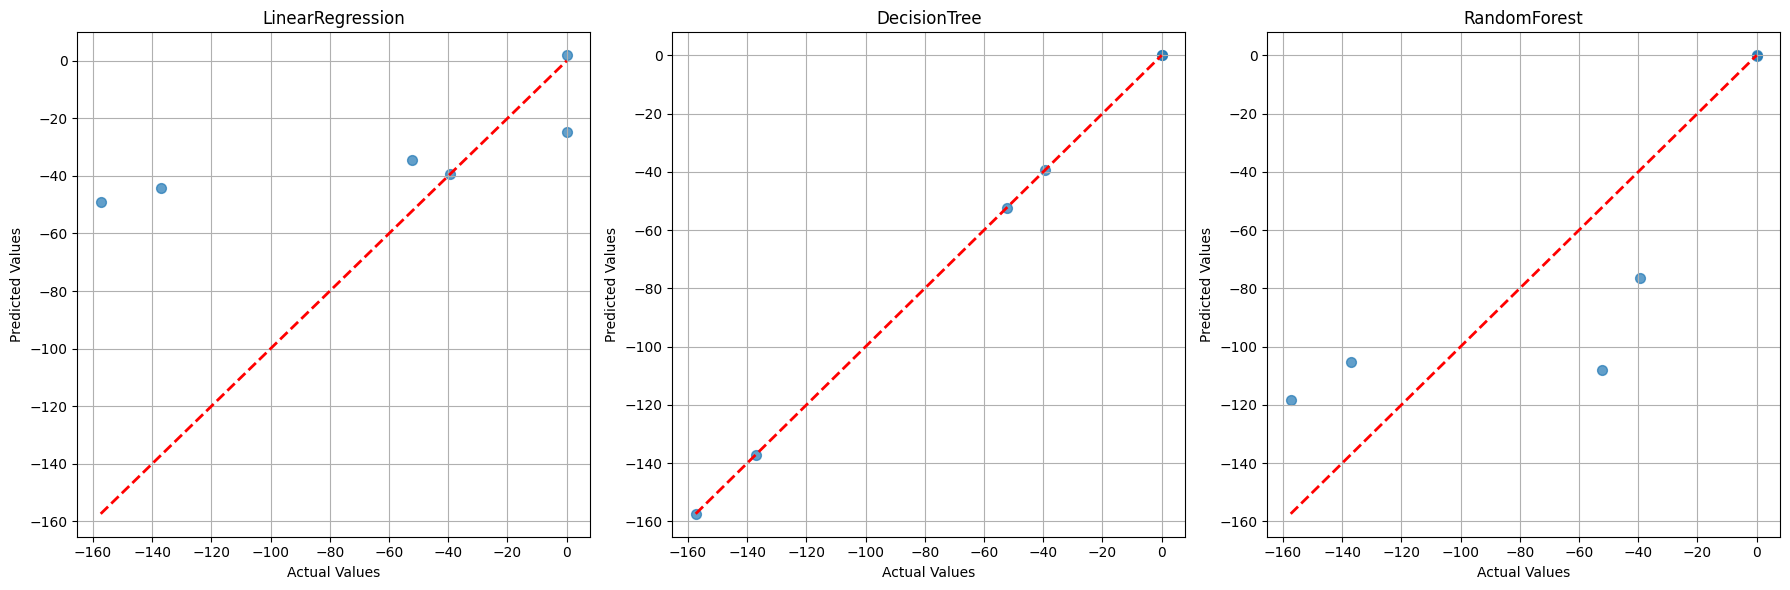

In [44]:

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

model_names = ['LinearRegression', 'DecisionTree', 'RandomForest']
for i, name in enumerate(model_names):
    axes[i].scatter(predictions['AVG(diff)'], predictions[name], alpha=0.7, s=50)
    # addin the ideal line (y=x)
    axes[i].plot([predictions['AVG(diff)'].min(), predictions['AVG(diff)'].max()], 
                 [predictions['AVG(diff)'].min(), predictions['AVG(diff)'].max()], 'r--', lw=2)
    axes[i].set_xlabel('Actual Values')
    axes[i].set_ylabel('Predicted Values')
    axes[i].set_title(name)
    axes[i].grid(True)

plt.tight_layout()
plt.show()

**answer**: all points would lie exactly on the red dashed line (y=x), forming a **perfect diagonal line**